In [1]:
#Classification Models

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler

In [3]:
clf_features_train = pd.read_csv("Data/Classification3/clf_features_train.csv", index_col=0)
clf_features_test  = pd.read_csv("Data/Classification3/clf_features_test.csv",  index_col=0)
clf_labels_train   = pd.read_csv("Data/Classification3/clf_labels_train.csv")["ArrDel15"].to_numpy()
clf_labels_test    = pd.read_csv("Data/Classification3/clf_labels_test.csv")["ArrDel15"].to_numpy()


scaler = StandardScaler()
clf_features_train_scaled = scaler.fit_transform(clf_features_train) 
clf_features_test_scaled  = scaler.transform(clf_features_test)   

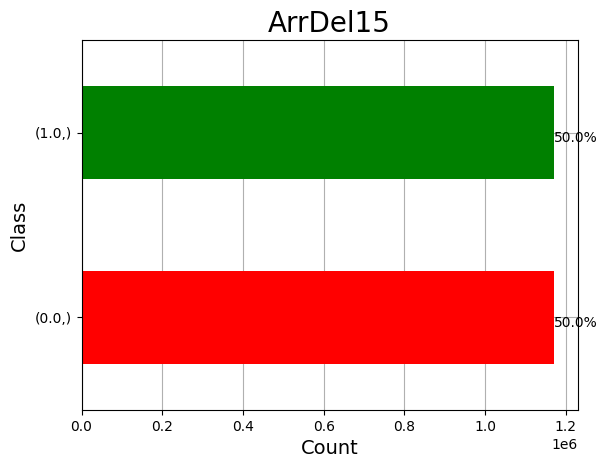

0  
0.0    1170702
1.0    1170702
Name: count, dtype: int64


In [4]:
#Training data
ax = pd.DataFrame(clf_labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(clf_labels_train).value_counts())
fig = ax.get_figure()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93    292676
         1.0       0.74      0.78      0.76     77612

    accuracy                           0.90    370288
   macro avg       0.84      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



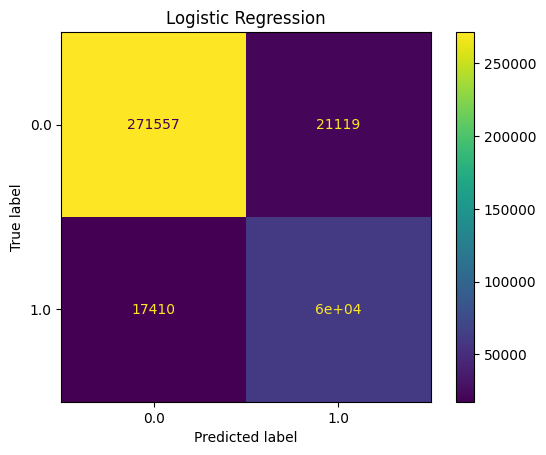

In [5]:
#Logistic Regression

# model = LogisticRegression(n_jobs=-1, max_iter=1000)
# model.fit(clf_features_train_scaled, clf_labels_train)
# joblib.dump(model, "./Data/Classification3/LogisticRegression.joblib")
model = joblib.load("./Data/Classification3/LogisticRegression.joblib")
model_pred = model.predict(clf_features_test_scaled)
#print(confusion_matrix(labels_test, model_pred))
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test_scaled, clf_labels_test)
plt.title("Logistic Regression")
plt.show()
del model
del model_pred

              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91    292676
         1.0       0.66      0.70      0.68     77612

    accuracy                           0.86    370288
   macro avg       0.79      0.80      0.80    370288
weighted avg       0.87      0.86      0.86    370288



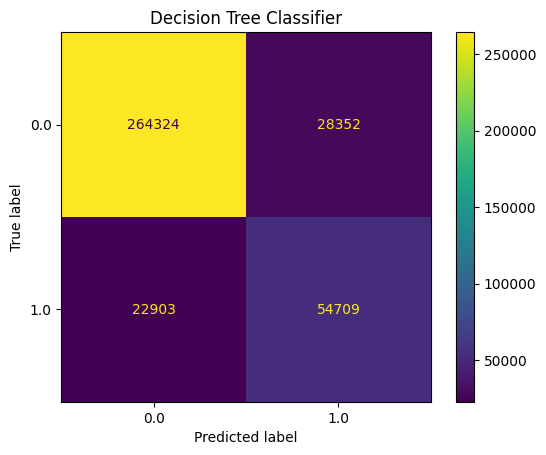

In [6]:
#Decision Tree Classifier

# model = DecisionTreeClassifier()
# model.fit(clf_features_train, clf_labels_train)
# joblib.dump(model, "./Data/Classification3/DecisionTreeClassifier.joblib")
model = joblib.load("./Data/Classification3/DecisionTreeClassifier.joblib")
model_pred = model.predict(clf_features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test, clf_labels_test)
plt.title("Decision Tree Classifier")
plt.show()
del model
del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94    292676
         1.0       0.81      0.74      0.77     77612

    accuracy                           0.91    370288
   macro avg       0.87      0.85      0.86    370288
weighted avg       0.91      0.91      0.91    370288



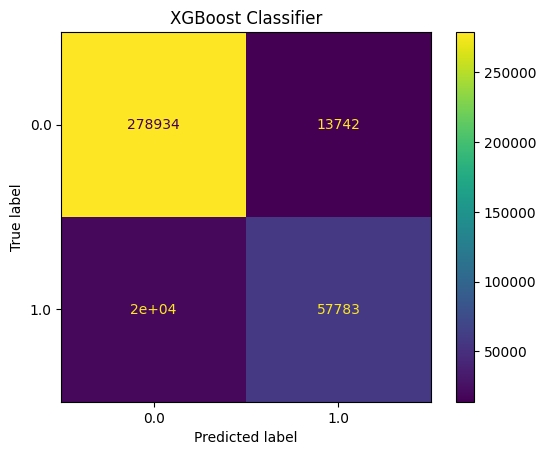

In [7]:
#XGBoost

# model = XGBClassifier(n_jobs=-1, eval_metric="logloss", random_state=42)
# model.fit(clf_features_train, clf_labels_train)
# joblib.dump(model, "Data/Classification3/XGBClassifier.joblib")
model = joblib.load("Data/Classification3/XGBClassifier.joblib")
model_pred = model.predict(clf_features_test)
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test, clf_labels_test)
plt.title("XGBoost Classifier")
plt.show()
del model
del model_pred

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94    292676
         1.0       0.77      0.76      0.77     77612

    accuracy                           0.90    370288
   macro avg       0.86      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



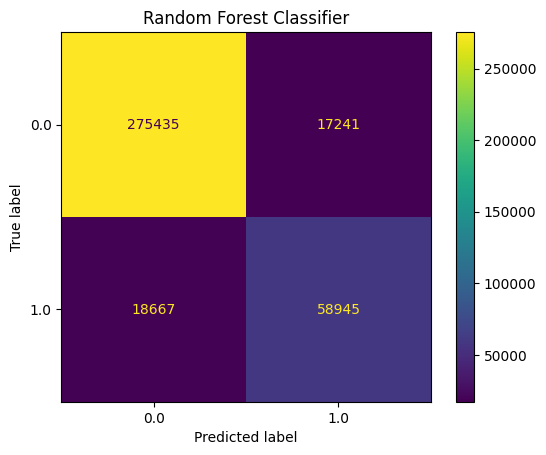

In [8]:
#Random Forest

# model = RandomForestClassifier(n_jobs=-1)
# model.fit(clf_features_train, clf_labels_train)
# joblib.dump(model, "./Data/Classification3/RandomForestClassifier.joblib")
model = joblib.load("./Data/Classification3/RandomForestClassifier.joblib")
model_pred = model.predict(clf_features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test, clf_labels_test)
plt.title("Random Forest Classifier")
plt.show()
del model
del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.94      0.94    292676
         1.0       0.78      0.73      0.76     77612

    accuracy                           0.90    370288
   macro avg       0.85      0.84      0.85    370288
weighted avg       0.90      0.90      0.90    370288



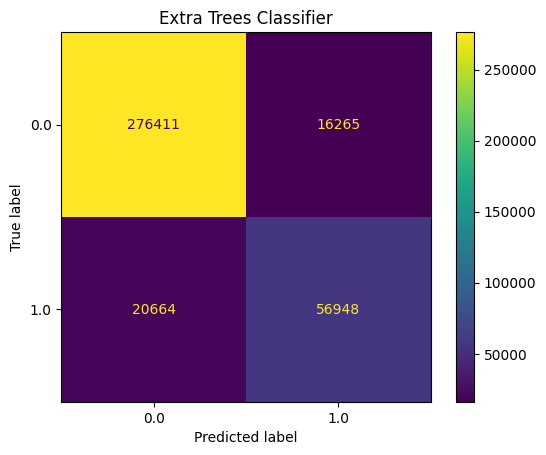

In [9]:
#Extra Trees

# model = ExtraTreesClassifier(n_jobs=-1)
# model.fit(clf_features_train, clf_labels_train)
# joblib.dump(model, "./Data/Classification3/ExtraTreesClassifier.joblib")
model = joblib.load("./Data/Classification3/ExtraTreesClassifier.joblib")
model_pred = model.predict(clf_features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test, clf_labels_test)
plt.title("Extra Trees Classifier")
plt.show()

In [10]:
# Setup — collect rows, then build the DataFrame once
rows = []

classifiers = ["DecisionTreeClassifier", "XGBClassifier", "RandomForestClassifier", "ExtraTreesClassifier"]
for clf in classifiers:
    model = joblib.load(f"./Data/Classification3/{clf}.joblib")
    model_pred2 = model.predict_proba(clf_features_test)[:, 1]
    fpr, tpr, _ = roc_curve(clf_labels_test, model_pred2)
    auc = roc_auc_score(clf_labels_test, model_pred2)
    rows.append({"classifiers": clf,
                 "fpr": fpr,
                 "tpr": tpr,
                 "auc": auc})
    del model
    del model_pred2

for clf in ["LogisticRegression"]:          # note: list, not a bare string
    model = joblib.load(f"./Data/Classification3/{clf}.joblib")
    model_pred3 = model.predict_proba(clf_features_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(clf_labels_test, model_pred3)
    auc = roc_auc_score(clf_labels_test, model_pred3)
    rows.append({"classifiers": clf,
                 "fpr": fpr,
                 "tpr": tpr,
                 "auc": auc})
    del model
    del model_pred3

# Build the DataFrame and set the index
perf_df = pd.DataFrame(rows, columns=["classifiers", "fpr", "tpr", "auc"])
perf_df.set_index("classifiers", inplace=True)

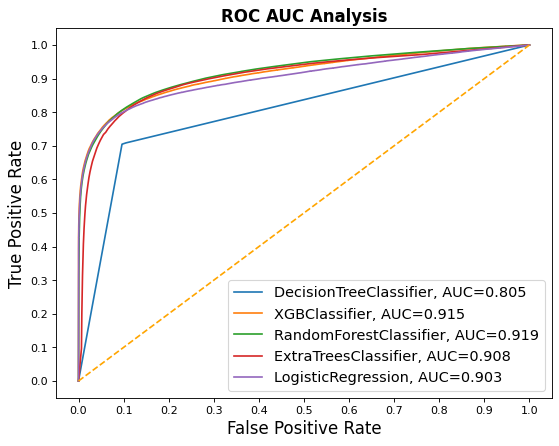

In [11]:
fig = plt.figure(figsize=(8,6), dpi=80)
for clf_name in perf_df.index:
    plt.plot(perf_df.loc[clf_name]["fpr"], 
             perf_df.loc[clf_name]["tpr"], 
             label="{}, AUC={:.3f}".format(clf_name, perf_df.loc[clf_name]["auc"]))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title("ROC AUC Analysis", fontweight="bold", fontsize=15)
plt.legend(prop={"size":13}, loc="lower right")

plt.show()

In [12]:
# Build a metrics table for all saved classifiers

# Map each model to the test set it was evaluated on (matches your classification_report calls)
model_specs = {
    "LogisticRegression":     clf_features_test_scaled,
    "DecisionTreeClassifier": clf_features_test,
    "XGBClassifier":          clf_features_test,
    "RandomForestClassifier": clf_features_test,
    "ExtraTreesClassifier":   clf_features_test,
}

rows = []
for name, X_test in model_specs.items():
    model = joblib.load(f"./Data/Classification3/{name}.joblib")
    pred = model.predict(X_test)
    rep = classification_report(clf_labels_test, pred,
                            labels=[0, 1], target_names=["0", "1"],
                            output_dict=True)
    rows.append({
        "Model":         name,
        "Accuracy":      rep["accuracy"],
        "Precision (0)": rep["0"]["precision"],
        "Precision (1)": rep["1"]["precision"],
        "Recall (0)":    rep["0"]["recall"],
        "Recall (1)":    rep["1"]["recall"],
        "F1 (0)":        rep["0"]["f1-score"],
        "F1 (1)":        rep["1"]["f1-score"],
    })
    del model, pred

metrics_df = (pd.DataFrame(rows)
              .set_index("Model")
              .sort_values("F1 (1)", ascending=False)
              .round(4))

metrics_df

,Accuracy,Precision (0),Precision (1),Recall (0),Recall (1),F1 (0),F1 (1)
Model,,,,,,,
XGBClassifier,0.9093,0.9336,0.8079,0.9530,0.7445,0.9432,0.7749
RandomForestClassifier,0.9030,0.9365,0.7737,0.9411,0.7595,0.9388,0.7665
LogisticRegression,0.8959,0.9398,0.7403,0.9278,0.7757,0.9338,0.7576
ExtraTreesClassifier,0.9003,0.9304,0.7778,0.9444,0.7338,0.9374,0.7552
DecisionTreeClassifier,0.8616,0.9203,0.6587,0.9031,0.7049,0.9116,0.6810
